# 05 — Model Evaluation and Prediction Maps

This notebook evaluates both trained classifiers (Random Forest and XGBoost) on the held-out spatial test set and visualises the results.

**Contents:**
1. Load models and reconstruct the spatial train/test split
2. Generate predictions and probabilities on the test set
3. Confusion matrices (side-by-side)
4. ROC curves with AUC
5. Interactive Folium prediction map
6. Geemap visualisation with Sentinel-2 background
7. Feature importance bar chart
8. Summary statistics

---
## 1. Imports and Setup

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import folium
from folium.plugins import MarkerCluster

from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import geemap
import ee

# Plotting defaults
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Ensure output directories exist
os.makedirs("../figures", exist_ok=True)

print("All imports successful.")

All imports successful.


---
## 2. Load Models and Data

We load the serialised Random Forest and XGBoost models that were saved during training (notebook 04), then reload the merged feature table.

In [2]:
# --- Load trained models -----------------------------------------------
rf_model = joblib.load("../models/random_forest.joblib")
xgb_model = joblib.load("../models/xgboost_model.joblib")
feature_names = joblib.load("../models/feature_names.joblib")

print(f"Random Forest : {rf_model}")
print(f"XGBoost       : {xgb_model}")
print(f"Features ({len(feature_names)}): {feature_names[:5]} ...")

Random Forest : RandomForestClassifier(class_weight='balanced', max_depth=30,
                       max_features='log2', min_samples_leaf=5,
                       n_estimators=200, n_jobs=-1, random_state=42)
XGBoost       : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=1,
              num_parallel_tree=None, ...)
F

In [3]:
# --- Load feature data --------------------------------------------------
df = pd.read_csv("../data/processed/features_merged.csv")
print(f"Loaded {len(df)} samples with {df.shape[1]} columns.")
df.head()

Loaded 5704 samples with 23 columns.


,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,...,label,point_id,VH,VV,VV_VH_ratio,aspect,elevation,slope,lat,lon
0,1501.0,662.0,339.0,505.0,304.0,782.0,2382.0,2939.0,2937.0,3239.0,...,1,0,-13.856659,-7.145652,6.711007,0,983,2,0.337021,28.715262
1,1934.0,881.5,430.5,614.0,392.0,969.5,2689.5,3221.0,3298.0,3578.5,...,1,1,-12.660043,-6.595626,6.064417,150,1026,10,0.321530,28.699160
2,1323.0,582.0,328.0,416.0,278.0,680.0,1962.0,2492.0,2486.0,2753.0,...,1,2,-13.241170,-6.643131,6.598038,305,768,6,0.544992,28.185142
3,1549.0,755.0,328.0,519.0,307.0,836.0,2213.0,2637.0,2626.0,2881.0,...,1,3,-12.169551,-5.409893,6.759657,5,1330,6,-0.352529,28.884528
4,1943.0,893.5,346.0,535.5,331.5,932.5,2907.0,3596.5,3615.0,3941.5,...,1,4,-14.135198,-7.807693,6.327505,221,1171,4,-0.036707,28.903945


---
## 3. Reconstruct the Spatial Train/Test Split

To ensure the evaluation is identical to training we reproduce the **KMeans-based spatial split** with the same parameters and `random_state`. Points are clustered by their geographic coordinates; entire clusters are assigned to either the training or test fold so that nearby points never leak across sets.

In [4]:
# --- Spatial split parameters (must match notebook 04) ------------------
N_CLUSTERS = 10
TEST_BLOCKS = {0, 1}
RANDOM_STATE = 42

# Reconstruct coordinates — use lat/lon if present, otherwise load from geojson
if "lat" in df.columns and "lon" in df.columns:
    coords = df[["lat", "lon"]].values
else:
    import geopandas as _gpd
    _pts = _gpd.read_file("../data/processed/all_labeled_points.geojson")
    coords = np.column_stack([_pts.geometry.y.values[df["point_id"].values],
                              _pts.geometry.x.values[df["point_id"].values]])

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(coords)

# Match notebook 04: blocks 0 and 1 are test
test_mask = df["cluster"].isin(TEST_BLOCKS)
train_mask = ~test_mask

print(f"Test clusters : {sorted(TEST_BLOCKS)}")
print(f"Train samples : {train_mask.sum()}")
print(f"Test samples  : {test_mask.sum()}")

Test clusters : [0, 1]
Train samples : 4191
Test samples  : 1513


In [5]:
# --- Prepare feature matrix and labels ----------------------------------
label_col = "label"

# Use the exact feature names saved during training
X_train = df.loc[train_mask, feature_names]
y_train = df.loc[train_mask, label_col]
X_test = df.loc[test_mask, feature_names]
y_test = df.loc[test_mask, label_col]

# Store coordinates for the test set (for mapping)
test_coords = coords[test_mask.values]

print(f"Features used : {len(feature_names)}")
print(f"Test label distribution:\n{y_test.value_counts().to_string()}")

Features used : 16
Test label distribution:
label
1    933
0    580


---
## 4. Predict on Test Set

In [6]:
# --- Random Forest predictions ------------------------------------------
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# --- XGBoost predictions ------------------------------------------------
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated for both models.")

Predictions generated for both models.


---
## 5. Confusion Matrices

Confusion matrices show the breakdown of correct and incorrect predictions for each class. The diagonal cells represent correct predictions; off-diagonal cells are errors.

- **Top-left (TN):** non-mine sites correctly classified
- **Bottom-right (TP):** mine sites correctly classified
- **Top-right (FP):** non-mine sites wrongly predicted as mines
- **Bottom-left (FN):** mine sites missed by the model

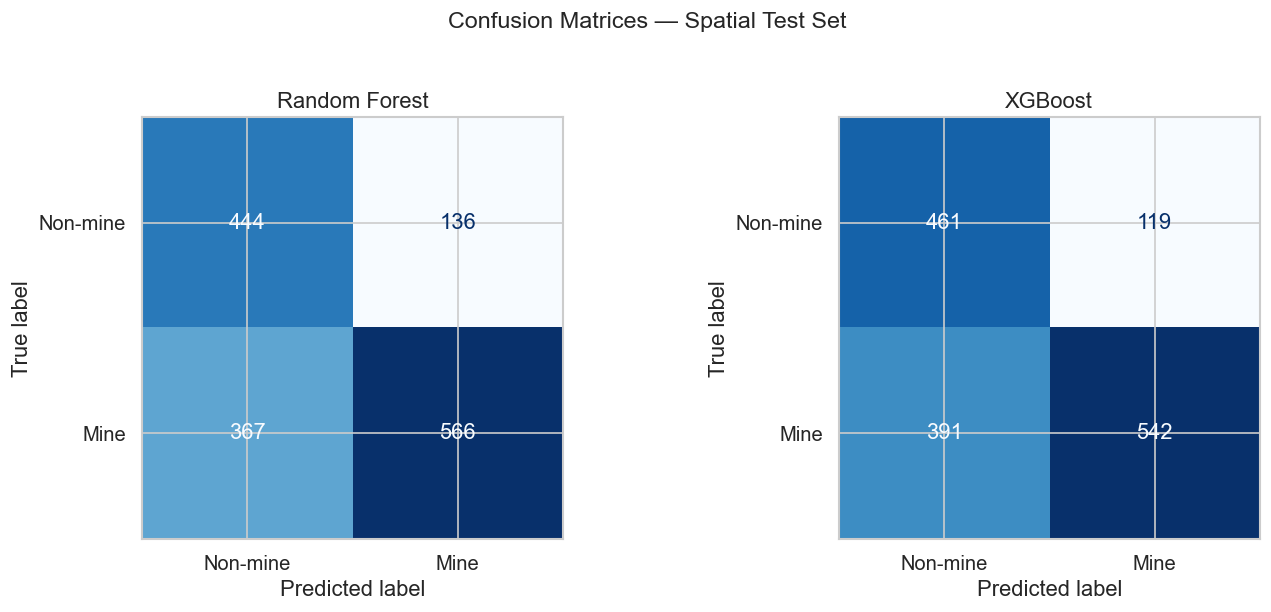

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name in zip(
    axes, [rf_preds, xgb_preds], ["Random Forest", "XGBoost"]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-mine", "Mine"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

fig.suptitle("Confusion Matrices — Spatial Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
print("=" * 60)
print("CLASSIFICATION REPORT — Random Forest")
print("=" * 60)
print(classification_report(y_test, rf_preds, target_names=["Non-mine", "Mine"]))

print("=" * 60)
print("CLASSIFICATION REPORT — XGBoost")
print("=" * 60)
print(classification_report(y_test, xgb_preds, target_names=["Non-mine", "Mine"]))

CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

    Non-mine       0.55      0.77      0.64       580
        Mine       0.81      0.61      0.69       933

    accuracy                           0.67      1513
   macro avg       0.68      0.69      0.67      1513
weighted avg       0.71      0.67      0.67      1513

CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

    Non-mine       0.54      0.79      0.64       580
        Mine       0.82      0.58      0.68       933

    accuracy                           0.66      1513
   macro avg       0.68      0.69      0.66      1513
weighted avg       0.71      0.66      0.67      1513



---
## 6. ROC Curves

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate against the False Positive Rate at every probability threshold. A model with perfect discrimination would hug the top-left corner (AUC = 1.0). The dashed diagonal represents a random baseline (AUC = 0.5).

Saved: ../figures/roc_curves.png


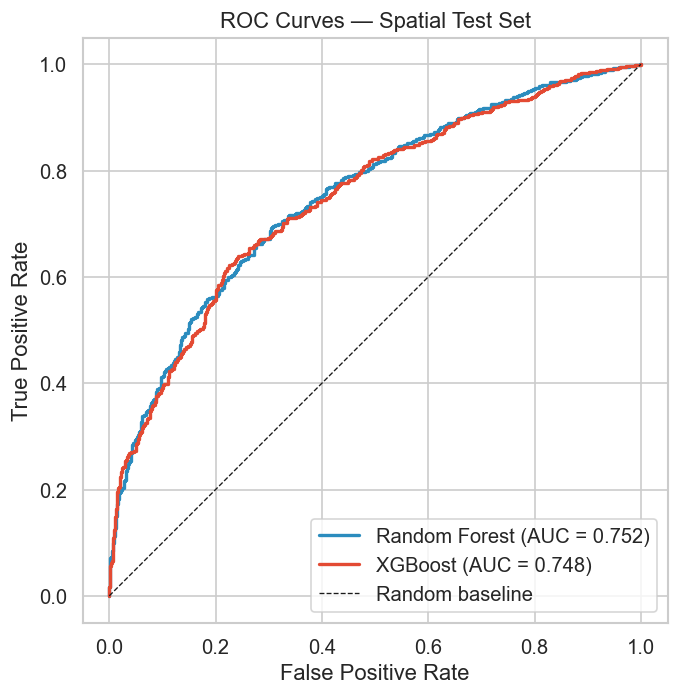

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

for probs, name, color in [
    (rf_probs, "Random Forest", "#2b8cbe"),
    (xgb_probs, "XGBoost", "#e34a33"),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", linewidth=2, color=color)

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Spatial Test Set")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
fig.savefig("../figures/roc_curves.png", dpi=200, bbox_inches="tight")
print("Saved: ../figures/roc_curves.png")
plt.show()

---
## 7. Interactive Folium Prediction Map

The map below shows every test-set point colour-coded by prediction outcome:

| Colour | Meaning | Interpretation |
|--------|---------|----------------|
| **Green** | True Positive | Mine correctly identified |
| **Blue** | True Negative | Non-mine correctly identified |
| **Orange** | False Positive | Non-mine misclassified as mine |
| **Red** | False Negative | Mine missed by model |

Click any marker to see the predicted probability.

In [10]:
# Use the best model for the map (choose by AUC)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

if xgb_auc >= rf_auc:
    best_name = "XGBoost"
    best_preds = xgb_preds
    best_probs = xgb_probs
else:
    best_name = "Random Forest"
    best_preds = rf_preds
    best_probs = rf_probs

print(f"Best model by AUC: {best_name}")

Best model by AUC: Random Forest


In [13]:
# Build test-set dataframe with results
test_df = pd.DataFrame({
    "lat": test_coords[:, 0],
    "lon": test_coords[:, 1],
    label_col: y_test.values,
    "pred": best_preds,
    "prob": best_probs,
})


def outcome_category(row):
    """Classify each prediction into TP / TN / FP / FN."""
    actual, pred = int(row[label_col]), int(row["pred"])
    if actual == 1 and pred == 1:
        return "True Positive"
    elif actual == 0 and pred == 0:
        return "True Negative"
    elif actual == 0 and pred == 1:
        return "False Positive"
    else:
        return "False Negative"


test_df["outcome"] = test_df.apply(outcome_category, axis=1)

OUTCOME_COLORS = {
    "True Positive": "green",
    "True Negative": "blue",
    "False Positive": "orange",
    "False Negative": "red",
}

# Centre the map on the study area
center_lat = test_df["lat"].mean()
center_lon = test_df["lon"].mean()

# Use satellite imagery as the default base layer
m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles=None)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri",
    name="Esri Satellite",
    overlay=False,
    control=True,
).add_to(m)

folium.TileLayer(
    tiles="OpenStreetMap",
    name="OpenStreetMap",
    overlay=False,
    control=True,
).add_to(m)

# Feature groups for layer control
groups = {}
for outcome in OUTCOME_COLORS:
    groups[outcome] = folium.FeatureGroup(name=outcome)

for _, row in test_df.iterrows():
    outcome = row["outcome"]
    popup_text = (
        f"<b>Outcome:</b> {outcome}<br>"
        f"<b>Actual:</b> {'Mine' if row[label_col] == 1 else 'Non-mine'}<br>"
        f"<b>Predicted:</b> {'Mine' if row['pred'] == 1 else 'Non-mine'}<br>"
        f"<b>Probability (mine):</b> {row['prob']:.3f}<br>"
        f"<b>Lat:</b> {row['lat']:.4f}, <b>Lon:</b> {row['lon']:.4f}"
    )
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=OUTCOME_COLORS[outcome],
        fill=True,
        fill_color=OUTCOME_COLORS[outcome],
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=280),
    ).add_to(groups[outcome])

for g in groups.values():
    g.add_to(m)

# Add layer control
folium.LayerControl(collapsed=False).add_to(m)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background-color: white; padding: 10px 14px; border: 2px solid grey;
            border-radius: 5px; font-size: 13px; line-height: 1.6;">
    <b>Prediction Outcome</b><br>
    <i style="background:green; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> True Positive (mine found)<br>
    <i style="background:blue;  width:12px; height:12px; display:inline-block; border-radius:50%;"></i> True Negative (non-mine)<br>
    <i style="background:orange;width:12px; height:12px; display:inline-block; border-radius:50%;"></i> False Positive (false alarm)<br>
    <i style="background:red;   width:12px; height:12px; display:inline-block; border-radius:50%;"></i> False Negative (mine missed)<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save
m.save("../figures/prediction_map.html")
print("Saved: ../figures/prediction_map.html")
m

Saved: ../figures/prediction_map.html


---
## 8. Geemap Visualisation (Sentinel-2)

Below we display a Sentinel-2 true-colour composite as background imagery and overlay the prediction results. This gives spatial context showing the landscape around each predicted location.

> **Note:** This cell requires a valid Earth Engine authentication. Run `ee.Authenticate()` first if you have not done so in this session.

In [14]:
# Initialise Earth Engine
try:
    ee.Initialize(project='concise-ion-489212-a9')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='concise-ion-489212-a9')

print("Earth Engine initialised.")

Earth Engine initialised.


In [15]:
# Create geemap Map centred on study area
Map = geemap.Map(center=[center_lat, center_lon], zoom=8)

# --- Sentinel-2 true-colour composite -----------------------------------
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2023-01-01", "2023-12-31")
    .filterBounds(ee.Geometry.Point([center_lon, center_lat]))
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .median()
)

vis_params = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 3000,
    "gamma": 1.4,
}
Map.addLayer(s2, vis_params, "Sentinel-2 True Colour")

# --- Overlay prediction points ------------------------------------------
OUTCOME_HEX = {
    "True Positive": "#00cc00",
    "True Negative": "#3366ff",
    "False Positive": "#ff9900",
    "False Negative": "#ff0000",
}

for outcome, color in OUTCOME_HEX.items():
    subset = test_df[test_df["outcome"] == outcome]
    if subset.empty:
        continue
    features = []
    for _, row in subset.iterrows():
        feat = ee.Feature(
            ee.Geometry.Point([row["lon"], row["lat"]]),
            {
                "outcome": outcome,
                "prob": float(row["prob"]),
            },
        )
        features.append(feat)
    fc = ee.FeatureCollection(features)
    Map.addLayer(
        fc.style(color=color, pointSize=4),
        {},
        outcome,
    )

Map.addLayerControl()
Map

Map(center=[np.float64(-0.8815705062592152), np.float64(28.163739632854526)], controls=(WidgetControl(options=…

---
## 9. Feature Importance

The bar chart below shows the 15 most important features according to the best-performing model. For tree-based models this is typically the mean decrease in impurity (Gini importance for RF) or gain (XGBoost). Features at the top contribute most to the model's predictions.

Saved: ../figures/feature_importance.png


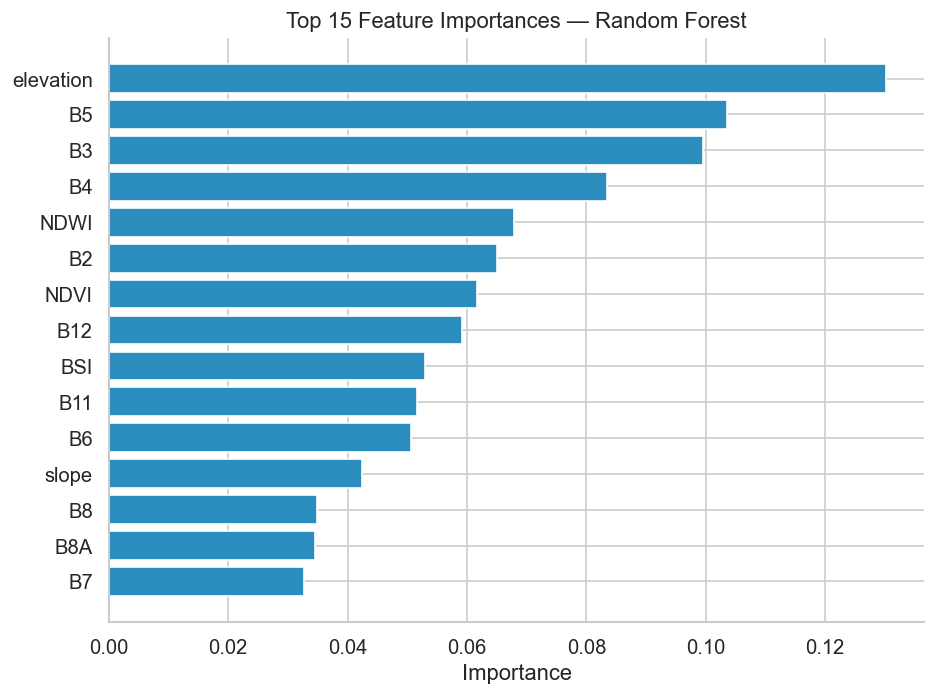

In [16]:
# Choose the best model
best_model = xgb_model if best_name == "XGBoost" else rf_model

importances = best_model.feature_importances_
feat_imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
    .sort_values("importance", ascending=True)  # ascending for horizontal bar
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_imp["feature"], feat_imp["importance"], color="#2b8cbe", edgecolor="white")
ax.set_xlabel("Importance")
ax.set_title(f"Top 15 Feature Importances — {best_name}")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig("../figures/feature_importance.png", dpi=200, bbox_inches="tight")
print("Saved: ../figures/feature_importance.png")
plt.show()

---
## 10. Summary Statistics

The table below compiles key metrics for both models, making it easy to compare their performance at a glance.

In [17]:
def compute_metrics(y_true, y_pred, y_prob):
    """Return a dictionary of standard classification metrics."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob),
    }


metrics_rf = compute_metrics(y_test, rf_preds, rf_probs)
metrics_xgb = compute_metrics(y_test, xgb_preds, xgb_probs)

summary = pd.DataFrame(
    {"Random Forest": metrics_rf, "XGBoost": metrics_xgb}
).T

# Format to 4 decimal places
summary_styled = summary.style.format("{:.4f}").set_caption(
    "Model Performance — Spatial Test Set"
)

print("\n" + "=" * 60)
print("FINAL METRICS SUMMARY")
print("=" * 60)
print(summary.to_string(float_format="{:.4f}".format))
print("=" * 60)
print(f"\nBest model by ROC AUC: {best_name} ({max(rf_auc, xgb_auc):.4f})")
print(f"Test set size        : {len(y_test)} samples")
print(f"Spatial clusters held out: {sorted(TEST_BLOCKS)}")

summary_styled


FINAL METRICS SUMMARY
               Accuracy  Precision  Recall  F1-score  ROC AUC
Random Forest    0.6675     0.8063  0.6066    0.6924   0.7520
XGBoost          0.6629     0.8200  0.5809    0.6801   0.7482

Best model by ROC AUC: Random Forest (0.7520)
Test set size        : 1513 samples
Spatial clusters held out: [0, 1]


,Accuracy,Precision,Recall,F1-score,ROC AUC
Random Forest,0.6675,0.8063,0.6066,0.6924,0.7520
XGBoost,0.6629,0.8200,0.5809,0.6801,0.7482


---
## Interpretation Guidance

**What to look for:**

- **High recall** is critical in mining detection: we want to minimise False Negatives (missed mines), because failing to identify an active mine has real consequences for policy and oversight.
- **Precision** matters for operational use: too many False Positives waste field-verification resources.
- **ROC AUC > 0.85** generally indicates a model that discriminates well between mine and non-mine locations.
- **Spatial test set performance** is more realistic than random splits because it tests whether the model generalises to unseen geographic regions, not just unseen rows.

**Common pitfalls:**

- If the confusion matrix shows very few False Negatives but many False Positives, the model is over-predicting mines — consider raising the classification threshold.
- If both models perform identically, the features may dominate over the algorithm choice and further gains require richer input data.
- Clusters of False Negatives on the map may indicate landscape types underrepresented in the training set.

**Next steps:**

- Cross-reference False Negative locations with recent high-resolution imagery.
- Consider threshold tuning (e.g., picking the threshold that maximises F1 or recall at a minimum precision).
- Explore SHAP values for instance-level explanations.